# Liu2024 S-JEPA Self-Supervised Pretraining — Native 500 Hz, Option B (corrected)

Self-supervised, subject-clean S-JEPA pretraining on Liu2024 at native 500 Hz with a
seconds-faithful temporal encoder. **No labels are used for the SSL objective.**

## Root cause of the previous `probe_pos` NaN
The failure (`Non-finite tensor detected: probe_pos; count=6090`) was the **spatial** positional
block: `6090 = 203 tokens × 30 dims` — the conv/temporal path was fine, the channel-position →
spatial-encoder path was not. Two compounding issues:
1. the notebook drove **braindecode `SignalJEPA` internals by hand** and passed a custom 500 Hz
   conv spec + `sfreq_features` through `feature_encoder__…` / `pos_encoder__…` kwargs whose
   handling is version-dependent and unverifiable;
2. channel coordinates were handed to that encoder in **meters, un-centered and un-normalized**,
   and its internal normalization produced the NaNs.

## Fix
A **self-contained, faithful S-JEPA** (per-channel conv feature encoder → spatial+temporal
positional encoding → context encoder, with an EMA target encoder and spatial-block masking).
The positional encoder is **finite by construction**: channel coordinates are centered and
scaled to the unit ball with an epsilon (no division by zero), the spatial embedding is a small
MLP on those normalized coordinates, and the temporal embedding is a bounded sinusoid. This also
removes all dependence on opaque braindecode internals and on whether the custom conv spec was
honored. Every requested finite check is kept and a probe isolates the spatial vs temporal path.

## 1. Imports

In [1]:
import os
import re
import sys
import json
import math
import random
import hashlib
import platform
from copy import deepcopy
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from scipy.io import loadmat
import mne

# NOTE: braindecode.models.SignalJEPA intentionally NOT used — see root-cause note above.

mne.set_log_level("WARNING")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

print("Imports loaded")
print("Python:", sys.version)
print("Platform:", platform.platform())

Imports loaded
Python: 3.11.15 | packaged by conda-forge | (main, Mar  5 2026, 16:45:40) [GCC 14.3.0]
Platform: Linux-6.14.0-37-generic-x86_64-with-glibc2.41


## 2. Minimal configuration

In [2]:
WORKING_DIR = Path.cwd().resolve().parent.parent

CONFIG = {
    # Paths
    "artifact_dir": str(WORKING_DIR / "artifacts" / "liu2024-sjepa-500hz-optionB-pretraining"),
    "source_extract_dir": str(WORKING_DIR / "liu2024_data" / "liu2024_figshare" / "sourcedata"),
    "experiment_name": "liu2024_sjepa_500hz_optionB_pretraining",
    "config_note": "Native 500 Hz Liu2024 S-JEPA SSL pretraining with seconds-scaled temporal encoder.",

    # Subject split: downstream subjects remain unseen during SSL pretraining.
    "train_subject_ids": list(range(1, 31)),
    "val_subject_ids": list(range(31, 41)),
    "downstream_only_subject_ids": list(range(41, 51)),

    # Fixed Liu2024 preprocessing for this experiment.
    "sfreq": 500.0,
    "source_unit": "microvolts",
    "final_model_unit": "microvolts",
    "reference_mode": "average",
    "filter_low": 0.5,
    "filter_high": 40.0,
    "filter_method": "fir",

    # Pretraining windows.
    # Recommended: full_trial uses all 8 s available in Liu2024 for SSL context.
    # Alternative: fixed_crop with pretrain_start_s=1.5 and pretrain_window_s=4.2 aligns exactly to downstream.
    "pretrain_window_mode": "full_trial",     # full_trial, fixed_crop, sliding
    "pretrain_start_s": 0.0,
    "pretrain_window_s": 8.0,
    "sliding_stop_s": 8.0,
    "sliding_stride_s": 1.0,

    # Option B seconds-scaled S-JEPA local encoder.
    "conv_spec_mode": "seconds_scaled_500hz",
    "first_kernel_s": 0.25,
    "first_stride_s_target": 1.0 / 16.0,       # default S-JEPA first stride at 128 Hz is 8 samples = 0.0625 s
    "first_stride_rounding": "floor",          # floor gives stride 31 samples; total token stride ~= 0.992 s
    "later_kernel_samples": 2,
    "later_stride_samples": 2,

    # Masking objective.
    "mask_diameter_percent": 60.0,
    "predictor_n_layers": 4,
    "predictor_nhead": 8,
    "predictor_dim_feedforward": 256,
    "ema_decay": 0.996,

    # Context (target/online) transformer encoder.
    "context_n_layers": 4,
    "context_nhead": 8,
    "context_dim_feedforward": 256,
    "context_dropout": 0.0,

    # Training.
    "batch_size": 8,
    "n_epochs": 300,
    "early_stopping_patience": 30,
    "learning_rate": 1e-4,   # 1e-4 is safer for the transformer context encoder than 1e-3
    "weight_decay": 1e-4,
    "num_workers": 0,

    # Runtime.
    "device": "auto",
    "seed": 2026,
}

## 3. Run setup and seconds-based temporal geometry

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def resolve_device(requested="auto"):
    requested = str(requested).lower()
    if requested == "cpu":
        return torch.device("cpu")
    if requested == "cuda":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def create_run_id(config):
    stamp = datetime.now().strftime("%Y%m%d_%H%M")
    digest = hashlib.md5(json.dumps(config, sort_keys=True, default=str).encode()).hexdigest()[:8]
    return f"{stamp}_500hz_{digest}"


def make_seconds_scaled_conv_spec(config):
    """Create a 500 Hz conv spec whose real-time behavior matches S-JEPA.

    Default S-JEPA at 128 Hz uses:
      (8, 32, 8), then four (kernel=2, stride=2) layers.
    That means:
      first kernel = 32/128 = 0.25 s
      total stride = 8*2*2*2*2 = 128 samples = 1.0 s
      receptive field = 152/128 = 1.1875 s

    At 500 Hz, we use first kernel ~= 125 samples and first stride ~= 31 samples.
    Total stride = 31*16 = 496 samples = 0.992 s.
    Receptive field = 590 samples = 1.18 s.
    """
    sfreq = float(config["sfreq"])
    k1 = int(round(float(config["first_kernel_s"]) * sfreq))
    raw_stride = float(config["first_stride_s_target"]) * sfreq
    if config.get("first_stride_rounding", "floor") == "floor":
        s1 = int(math.floor(raw_stride))
    elif config.get("first_stride_rounding") == "ceil":
        s1 = int(math.ceil(raw_stride))
    else:
        s1 = int(round(raw_stride))
    s1 = max(1, s1)
    k_later = int(config["later_kernel_samples"])
    s_later = int(config["later_stride_samples"])
    spec = (
        (8, k1, s1),
        (16, k_later, s_later),
        (32, k_later, s_later),
        (64, k_later, s_later),
        (64, k_later, s_later),
    )
    return spec


def conv_geometry(conv_spec, n_times, sfreq):
    out = int(n_times)
    total_stride = 1
    receptive = 1
    running_stride = 1
    for _, kernel, stride in conv_spec:
        out = (out - int(kernel)) // int(stride) + 1
        receptive = receptive + (int(kernel) - 1) * running_stride
        running_stride *= int(stride)
        total_stride *= int(stride)
    return {
        "n_tokens_per_channel": int(out),
        "total_stride_samples": int(total_stride),
        "token_sfreq_hz": float(sfreq) / float(total_stride),
        "token_stride_s": float(total_stride) / float(sfreq),
        "receptive_field_samples": int(receptive),
        "receptive_field_s": float(receptive) / float(sfreq),
    }


set_seed(CONFIG["seed"])
DEVICE = resolve_device(CONFIG["device"])
RUN_ID = create_run_id(CONFIG)
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONV_LAYERS_SPEC = make_seconds_scaled_conv_spec(CONFIG)

with open(ARTIFACT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Artifact dir:", ARTIFACT_DIR)
print("Device:", DEVICE)
print("Conv spec:", CONV_LAYERS_SPEC)

Artifact dir: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-sjepa-500hz-optionB-pretraining/20260614_1457_500hz_bff15bb4
Device: cpu
Conv spec: ((8, 125, 31), (16, 2, 2), (32, 2, 2), (64, 2, 2), (64, 2, 2))


## 4. Liu2024 channel metadata + robust, finite channel coordinates

Builds `chs_info` from `standard_1020` with old-name aliases (T3→T7, …), preserves the Liu2024
channel names, and produces **normalized** coordinates (`CH_POS_NORM`, centered + scaled to the
unit ball with epsilon) for the spatial positional encoder — the values that previously caused
NaNs are made well-conditioned here. A coordinate audit table is printed and any missing or
degenerate coordinate raises a clear error.

In [4]:
SOURCE_EEG_CHANNEL_INDICES_30 = list(range(30))
SOURCE_REFERENCE_INDEX = 17  # CPz source reference in Liu2024 source MAT
SOURCE_EEG_CHANNEL_INDICES_29 = [i for i in SOURCE_EEG_CHANNEL_INDICES_30 if i != SOURCE_REFERENCE_INDEX]

SOURCE_EEG_CHANNEL_NAMES_30 = [
    "Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FCz", "FC3", "FC4",
    "FT7", "FT8", "Cz", "C3", "C4", "T3", "T4", "CPz",
    "CP3", "CP4", "TP7", "TP8", "Pz", "P3", "P4", "T5", "T6", "Oz", "O1", "O2",
]
CH_NAMES = [SOURCE_EEG_CHANNEL_NAMES_30[i] for i in SOURCE_EEG_CHANNEL_INDICES_29]
MONTAGE_ALIAS = {"T3": "T7", "T4": "T8", "T5": "P7", "T6": "P8"}

def build_channel_coordinates(ch_names):
    """Return (chs_info, xyz_meters, ch_pos_norm, audit_df). Raises on any missing/degenerate coord."""
    montage = mne.channels.make_standard_montage("standard_1020")
    ch_pos = montage.get_positions()["ch_pos"]
    info = mne.create_info(ch_names=list(ch_names), sfreq=float(CONFIG["sfreq"]), ch_types="eeg")
    xyz = np.zeros((len(ch_names), 3), dtype=np.float64)
    used = []
    for k, ch in enumerate(info["chs"]):
        name = ch["ch_name"]
        lookup = MONTAGE_ALIAS.get(name, name)
        if lookup not in ch_pos:
            raise RuntimeError(f"Missing montage coordinate for '{name}' (lookup '{lookup}'). "
                               f"Add an alias in MONTAGE_ALIAS.")
        pos = np.asarray(ch_pos[lookup], dtype=np.float64)
        if not np.isfinite(pos).all():
            raise RuntimeError(f"Non-finite montage coordinate for '{name}'.")
        loc = np.zeros(12, dtype=float); loc[:3] = pos
        ch["loc"][:] = loc
        xyz[k] = pos
        used.append(lookup)

    # finite / non-degenerate checks
    if not np.isfinite(xyz).all():
        raise RuntimeError("Non-finite channel coordinates after assembly.")
    axis_range = xyz.max(0) - xyz.min(0)
    if np.any(axis_range <= 1e-8):
        raise RuntimeError(f"Degenerate coordinate axis (range={axis_range}). Montage not 3-D.")
    # duplicate-position guard (two channels at the same point would break spatial encoding)
    from scipy.spatial.distance import pdist
    if pdist(xyz).min() <= 1e-9:
        raise RuntimeError("Two channels share identical coordinates; check names/aliases.")

    # normalized coordinates for the positional encoder: center + scale to unit ball, eps-safe
    center = xyz.mean(0)
    centered = xyz - center
    radius = float(np.linalg.norm(centered, axis=1).max())
    ch_pos_norm = (centered / (radius + 1e-8)).astype(np.float32)
    if not np.isfinite(ch_pos_norm).all():
        raise RuntimeError("Non-finite normalized coordinates (should be impossible with eps).")

    audit = pd.DataFrame({
        "ch_name": list(ch_names), "montage_lookup": used,
        "x_m": xyz[:, 0].round(4), "y_m": xyz[:, 1].round(4), "z_m": xyz[:, 2].round(4),
        "nx": ch_pos_norm[:, 0].round(3), "ny": ch_pos_norm[:, 1].round(3), "nz": ch_pos_norm[:, 2].round(3),
        "norm": np.linalg.norm(ch_pos_norm, axis=1).round(3),
    })
    return info["chs"], xyz, ch_pos_norm, audit

CHS_INFO, CH_XYZ_M, CH_POS_NORM, COORD_AUDIT = build_channel_coordinates(CH_NAMES)
CH_POSITIONS = torch.tensor(CH_XYZ_M.astype(np.float32))        # meters, for mask-sampler distances
CH_POS_NORM_T = torch.tensor(CH_POS_NORM)                        # normalized, for the pos encoder

print(f"Channels: {len(CH_NAMES)}")
print(CH_NAMES)
print("\nCoordinate audit (normalized coords are finite, |norm|<=1):")
try:
    from IPython.display import display; display(COORD_AUDIT)
except Exception:
    print(COORD_AUDIT.to_string(index=False))
assert np.isfinite(CH_POS_NORM).all()
print(f"\nAll {len(CH_NAMES)} channel coordinates finite; max |norm| = {np.linalg.norm(CH_POS_NORM,axis=1).max():.3f}")


Channels: 29
['Fp1', 'Fp2', 'Fz', 'F3', 'F4', 'F7', 'F8', 'FCz', 'FC3', 'FC4', 'FT7', 'FT8', 'Cz', 'C3', 'C4', 'T3', 'T4', 'CP3', 'CP4', 'TP7', 'TP8', 'Pz', 'P3', 'P4', 'T5', 'T6', 'Oz', 'O1', 'O2']

Coordinate audit (normalized coords are finite, |norm|<=1):


,ch_name,montage_lookup,x_m,y_m,z_m,nx,ny,nz,norm
0,Fp1,Fp1,-0.0294,0.0839,-0.0070,-0.273,0.899,-0.325,0.994
1,Fp2,Fp2,0.0299,0.0849,-0.0071,0.264,0.908,-0.326,1.000
2,Fz,Fz,0.0003,0.0585,0.0665,-0.003,0.669,0.340,0.750
3,F3,F3,-0.0502,0.0531,0.0422,-0.461,0.620,0.120,0.782
4,F4,F4,0.0518,0.0543,0.0408,0.463,0.631,0.108,0.790
5,F7,F7,-0.0703,0.0425,-0.0114,-0.642,0.524,-0.365,0.905
6,F8,F8,0.0730,0.0444,-0.0120,0.655,0.542,-0.370,0.927
7,FCz,FCz,0.0004,0.0274,0.0887,-0.003,0.387,0.541,0.665
8,FC3,FC3,-0.0602,0.0227,0.0555,-0.551,0.345,0.241,0.693
9,FC4,FC4,0.0623,0.0237,0.0556,0.558,0.354,0.242,0.703



All 29 channel coordinates finite; max |norm| = 1.000


## 5. Load and preprocess Liu2024 source MAT files

In [5]:
def find_source_mat_files(root):
    root = Path(root)
    return sorted(root.rglob("*.mat")) if root.exists() else []


def subject_id_from_path(path):
    text = str(path)
    match = re.search(r"sub[-_ ]?(\d{1,2})", text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))
    nums = re.findall(r"\d+", Path(path).stem)
    if nums:
        return int(nums[-1])
    raise ValueError(f"Could not infer subject id from {path}")


def _is_mat_struct(x):
    return hasattr(x, "_fieldnames")


def _walk_mat_object(obj, prefix=""):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if str(k).startswith("__"):
                continue
            name = f"{prefix}.{k}" if prefix else str(k)
            yield name, v
            yield from _walk_mat_object(v, name)
    elif _is_mat_struct(obj):
        for k in obj._fieldnames:
            v = getattr(obj, k)
            name = f"{prefix}.{k}" if prefix else str(k)
            yield name, v
            yield from _walk_mat_object(v, name)
    elif isinstance(obj, np.ndarray) and obj.dtype == object:
        if obj.size == 1:
            yield from _walk_mat_object(obj.item(), prefix)
        else:
            for idx, item in np.ndenumerate(obj):
                yield from _walk_mat_object(item, f"{prefix}{idx}")


def _score_raw_candidate(name, arr):
    lname = name.lower()
    score = 0
    if any(token in lname for token in ["rawdata", "raw", "data"]):
        score += 10
    if arr.ndim == 3:
        score += 5
    if any(size in (39, 40) for size in arr.shape):
        score += 3
    if max(arr.shape) >= 3000:
        score += 2
    return score


def _score_label_candidate(name, arr):
    lname = name.lower()
    flat = np.asarray(arr).ravel()
    score = 0
    if "label" in lname or "class" in lname:
        score += 10
    if flat.size in (39, 40):
        score += 5
    unique = set(np.unique(flat).astype(str).tolist()) if flat.size <= 200 else set()
    if unique and unique.issubset({"0", "1", "2", "1.0", "2.0", "0.0"}):
        score += 3
    return score


def _normalize_rawdata_shape(rawdata, labels=None):
    arr = np.asarray(rawdata)
    if arr.ndim != 3:
        raise ValueError(f"Expected 3D rawdata, got shape={arr.shape}")
    if labels is not None:
        n_labels = int(np.asarray(labels).size)
        trial_axes = [axis for axis, size in enumerate(arr.shape) if size == n_labels]
    else:
        trial_axes = []
    if not trial_axes:
        trial_axes = [axis for axis, size in enumerate(arr.shape) if size in (39, 40)]
    if trial_axes and trial_axes[0] != 0:
        arr = np.moveaxis(arr, trial_axes[0], 0)
    time_axis = int(np.argmax(arr.shape[1:]) + 1)
    if time_axis != 2:
        arr = np.moveaxis(arr, time_axis, 2)
    if arr.shape[1] < 30 or arr.shape[2] < 3000:
        raise ValueError(f"Could not normalize to trials x channels x samples, got {arr.shape}")
    return arr


def load_subject_mat(path):
    mat = loadmat(path, squeeze_me=True, struct_as_record=False)
    raw_candidates = []
    label_candidates = []
    for name, value in _walk_mat_object(mat):
        if isinstance(value, np.ndarray):
            arr = np.asarray(value)
            if arr.ndim == 3:
                raw_candidates.append((_score_raw_candidate(name, arr), name, arr))
            flat = arr.ravel()
            if flat.size in (39, 40):
                label_candidates.append((_score_label_candidate(name, arr), name, arr))
    if not raw_candidates:
        raise RuntimeError(f"No rawdata candidate found in {path}")
    raw_candidates.sort(key=lambda x: x[0], reverse=True)
    label_candidates.sort(key=lambda x: x[0], reverse=True)
    raw_name, raw = raw_candidates[0][1], raw_candidates[0][2]
    if not label_candidates:
        raise RuntimeError(f"No label candidate found in {path}")
    label_name, labels = label_candidates[0][1], label_candidates[0][2]
    raw = _normalize_rawdata_shape(raw, labels)
    labels = np.asarray(labels).ravel().astype(int)
    if labels.min() == 1:
        labels = labels - 1
    if raw.shape[0] != labels.size:
        raise RuntimeError(f"Trial/label mismatch for {path}: raw={raw.shape}, labels={labels.shape}")
    return raw, labels.astype(np.int64), raw_name, label_name


def preprocess_subject(rawdata, labels, subject_id):
    """Return preprocessed full 8 s trials as microvolts, shape trials x 29 x 4000.

    MNE FIR filtering expects float64 input in recent versions.  Keep the
    filtering/reference path in float64, then cast back to float32 only after
    preprocessing so the training tensors remain compact.
    """
    X = np.asarray(rawdata[:, SOURCE_EEG_CHANNEL_INDICES_29, :], dtype=np.float64)
    y = np.asarray(labels, dtype=np.int64)

    # Convert to volts for MNE filtering, average-reference before filter, then return microvolts.
    X_volts = X * 1e-6 if CONFIG["source_unit"] == "microvolts" else X
    X_volts = np.asarray(X_volts, dtype=np.float64, order="C")
    if CONFIG["reference_mode"] == "average":
        X_volts = X_volts - X_volts.mean(axis=1, keepdims=True)
        X_volts = np.asarray(X_volts, dtype=np.float64, order="C")
    X_volts = mne.filter.filter_data(
        X_volts,
        sfreq=float(CONFIG["sfreq"]),
        l_freq=float(CONFIG["filter_low"]),
        h_freq=float(CONFIG["filter_high"]),
        method=CONFIG["filter_method"],
        phase="zero",
        fir_design="firwin",
        verbose=False,
    )
    X_uv = X_volts * 1e6 if CONFIG["final_model_unit"] == "microvolts" else X_volts
    return X_uv.astype(np.float32, copy=False), y


def make_pretraining_windows(X_full_trials, y):
    sfreq = float(CONFIG["sfreq"])
    n_times = X_full_trials.shape[-1]
    mode = CONFIG["pretrain_window_mode"]
    windows = []
    labels = []

    if mode == "full_trial":
        start = 0
        length = n_times
        windows = [X_full_trials]
        labels = [y]
    elif mode == "fixed_crop":
        start = int(round(float(CONFIG["pretrain_start_s"]) * sfreq))
        length = int(round(float(CONFIG["pretrain_window_s"]) * sfreq))
        stop = start + length
        if stop > n_times:
            raise RuntimeError(f"fixed_crop [{start}:{stop}] exceeds trial length {n_times}")
        windows = [X_full_trials[:, :, start:stop]]
        labels = [y]
    elif mode == "sliding":
        length = int(round(float(CONFIG["pretrain_window_s"]) * sfreq))
        start0 = int(round(float(CONFIG["pretrain_start_s"]) * sfreq))
        stop_limit = int(round(float(CONFIG["sliding_stop_s"]) * sfreq))
        stride = int(round(float(CONFIG["sliding_stride_s"]) * sfreq))
        for start in range(start0, stop_limit - length + 1, stride):
            windows.append(X_full_trials[:, :, start:start + length])
            labels.append(y)
    else:
        raise ValueError("pretrain_window_mode must be full_trial, fixed_crop, or sliding")

    Xw = np.concatenate(windows, axis=0).astype(np.float32)
    yw = np.concatenate(labels, axis=0).astype(np.int64)
    return Xw, yw


class ArrayDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.zeros(len(self.X), dtype=np.int64) if y is None else np.asarray(y, dtype=np.int64)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), int(self.y[idx])

## 6. Build train/validation SSL datasets (subjects 1–30 train, 31–40 val; 41–50 excluded)

In [6]:
SOURCE_EXTRACT_DIR = Path(CONFIG["source_extract_dir"])
mat_files = find_source_mat_files(SOURCE_EXTRACT_DIR)
if not mat_files:
    raise RuntimeError(f"No .mat files found under {SOURCE_EXTRACT_DIR}")

all_subject_paths = {subject_id_from_path(path): path for path in mat_files}
required = set(CONFIG["train_subject_ids"] + CONFIG["val_subject_ids"] + CONFIG["downstream_only_subject_ids"])
missing = sorted(required - set(all_subject_paths))
if missing:
    raise RuntimeError(f"Missing expected subject files: {missing}")

SUBJECT_WINDOWS = {}
rows = []
for sid in sorted(set(CONFIG["train_subject_ids"] + CONFIG["val_subject_ids"])):
    raw, labels, raw_field, label_field = load_subject_mat(all_subject_paths[sid])
    X_trials, y = preprocess_subject(raw, labels, sid)
    Xw, yw = make_pretraining_windows(X_trials, y)
    SUBJECT_WINDOWS[str(sid)] = ArrayDataset(Xw, yw)
    rows.append({
        "subject_id": sid,
        "raw_shape": list(raw.shape),
        "preprocessed_trial_shape": list(X_trials.shape),
        "window_shape": list(Xw.shape),
        "n_windows": int(len(Xw)),
        "class_0": int((yw == 0).sum()),
        "class_1": int((yw == 1).sum()),
        "raw_field": raw_field,
        "label_field": label_field,
    })

inventory = pd.DataFrame(rows)
inventory.to_csv(ARTIFACT_DIR / "subject_window_inventory.csv", index=False)
display(inventory.head())
print("Total SSL train windows:", sum(len(SUBJECT_WINDOWS[str(s)]) for s in CONFIG["train_subject_ids"]))
print("Total SSL val windows:", sum(len(SUBJECT_WINDOWS[str(s)]) for s in CONFIG["val_subject_ids"]))

WINDOW_SAMPLES = int(inventory.iloc[0]["window_shape"][-1])
INPUT_WINDOW_SECONDS = WINDOW_SAMPLES / float(CONFIG["sfreq"])
GEOMETRY = conv_geometry(CONV_LAYERS_SPEC, WINDOW_SAMPLES, float(CONFIG["sfreq"]))
print("Window samples:", WINDOW_SAMPLES)
print("Input seconds:", INPUT_WINDOW_SECONDS)
print("Token geometry:", GEOMETRY)
if GEOMETRY["n_tokens_per_channel"] < 2:
    raise RuntimeError("Too few tokens per channel. Increase pretrain_window_s or use full_trial.")

,subject_id,raw_shape,preprocessed_trial_shape,window_shape,n_windows,class_0,class_1,raw_field,label_field
0,1,"[40, 33, 4000]","[40, 29, 4000]","[40, 29, 4000]",40,20,20,eeg.rawdata,eeg.label
1,2,"[40, 33, 4000]","[40, 29, 4000]","[40, 29, 4000]",40,20,20,eeg.rawdata,eeg.label
2,3,"[40, 33, 4000]","[40, 29, 4000]","[40, 29, 4000]",40,20,20,eeg.rawdata,eeg.label
3,4,"[40, 33, 4000]","[40, 29, 4000]","[40, 29, 4000]",40,20,20,eeg.rawdata,eeg.label
4,5,"[40, 33, 4000]","[40, 29, 4000]","[40, 29, 4000]",40,20,20,eeg.rawdata,eeg.label


Total SSL train windows: 1200
Total SSL val windows: 400
Window samples: 4000
Input seconds: 8.0
Token geometry: {'n_tokens_per_channel': 7, 'total_stride_samples': 496, 'token_sfreq_hz': 1.0080645161290323, 'token_stride_s': 0.992, 'receptive_field_samples': 590, 'receptive_field_s': 1.18}


## 7. Self-contained S-JEPA: feature encoder, finite positional encoder, context/target encoders

A faithful S-JEPA built from standard, inspectable parts. The **positional encoder is finite by
construction** — spatial = small MLP on normalized coordinates, temporal = bounded sinusoid.

In [7]:
def assert_finite(name, tensor):
    if not torch.isfinite(tensor).all():
        bad = int((~torch.isfinite(tensor)).sum().item())
        raise RuntimeError(f"Non-finite tensor detected: {name}; count={bad}")


class ConvFeatureEncoder(nn.Module):
    """Per-channel temporal conv stack (S-JEPA local encoder). (B,C,T) -> (B,C,n_tok,D)."""
    def __init__(self, conv_spec):
        super().__init__()
        blocks, in_ch = [], 1
        for out_ch, k, s in conv_spec:
            blocks += [nn.Conv1d(in_ch, int(out_ch), kernel_size=int(k), stride=int(s)),
                       nn.GELU(), nn.GroupNorm(1, int(out_ch))]   # GroupNorm: batch-size-independent, stable
            in_ch = int(out_ch)
        self.net = nn.Sequential(*blocks); self.out_dim = in_ch
    def forward(self, x):
        B, C, T = x.shape
        h = self.net(x.reshape(B * C, 1, T))         # (B*C, D, n_tok)
        D, n_tok = h.shape[1], h.shape[-1]
        return h.permute(0, 2, 1).reshape(B, C, n_tok, D)


class PositionalEncoder(nn.Module):
    """Finite-by-construction PE: spatial = MLP(normalized xyz); temporal = bounded sinusoid."""
    def __init__(self, d_model, ch_pos_norm, max_tokens=8192):
        super().__init__()
        assert d_model % 2 == 0, "d_model must be even for sinusoidal PE"
        self.d_model = d_model
        self.register_buffer("ch_pos", torch.as_tensor(ch_pos_norm, dtype=torch.float32))
        self.spatial_mlp = nn.Sequential(nn.Linear(3, d_model), nn.GELU(), nn.Linear(d_model, d_model))
        pe = torch.zeros(max_tokens, d_model)
        pos = torch.arange(max_tokens, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("temporal_pe", pe)
    def spatial(self):                 # (C, D)
        return self.spatial_mlp(self.ch_pos)
    def temporal(self, n_tok):         # (n_tok, D)
        return self.temporal_pe[:n_tok]
    def forward(self, n_chans, n_tok):  # (C*n_tok, D), channel-major to match feature flattening
        sp = self.spatial()                       # (C, D)
        tp = self.temporal(n_tok)                 # (n_tok, D)
        return (sp[:, None, :] + tp[None, :, :]).reshape(n_chans * n_tok, self.d_model)


class SJEPABackbone(nn.Module):
    """feature_encoder -> (+ positional) -> context_encoder. EMA-copied to form the target encoder."""
    def __init__(self, conv_spec, ch_pos_norm, n_layers, nhead, dim_ff, dropout):
        super().__init__()
        self.feature_encoder = ConvFeatureEncoder(conv_spec)
        D = self.feature_encoder.out_dim
        self.pos_encoder = PositionalEncoder(D, ch_pos_norm)
        layer = nn.TransformerEncoderLayer(d_model=D, nhead=nhead, dim_feedforward=dim_ff,
                                           dropout=dropout, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.context_encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.d_model = D
    def tokens_pe(self, x):
        local = self.feature_encoder(x)                 # (B,C,n_tok,D)
        B, C, n_tok, D = local.shape
        pe = self.pos_encoder(C, n_tok)                 # (C*n_tok, D)
        return local.reshape(B, C * n_tok, D), pe, (B, C, n_tok, D)


class MaskedTokenPredictor(nn.Module):
    def __init__(self, d_model=64, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.0):
        super().__init__()
        layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                           dropout=dropout, batch_first=True, activation="gelu", norm_first=True)
        self.decoder = nn.TransformerDecoder(layer, num_layers=num_layers)
    def forward(self, context_tokens, masked_queries):
        return self.decoder(tgt=masked_queries, memory=context_tokens)


class RandomSpatialBlockMaskSampler:
    """Mask a spatial block of channels (all their tokens). Token-major flatten matches the encoder."""
    def __init__(self, ch_positions, ch_names, mask_diameter_percent, n_tok_per_channel):
        self.ch_positions = torch.as_tensor(ch_positions, dtype=torch.float32)
        self.ch_names = list(ch_names); self.n_channels = len(ch_names)
        self.n_tok_per_channel = int(n_tok_per_channel)
        dists = torch.cdist(self.ch_positions, self.ch_positions)
        self.head_diameter = float(dists.max().item())
        self.mask_diameter_percent = float(mask_diameter_percent)
        self.mask_radius = (self.mask_diameter_percent / 100.0) * self.head_diameter / 2.0
        self.distances = dists
    def sample_one(self, device):
        center = random.randrange(self.n_channels)
        mask_ch = self.distances[center] <= self.mask_radius
        if bool(mask_ch.all()):
            mask_ch[int(torch.argmax(self.distances[center]).item())] = False
        if not bool(mask_ch.any()):
            mask_ch[center] = True
        mask_tok = mask_ch.repeat_interleave(self.n_tok_per_channel).to(device)
        return mask_ch.to(device), mask_tok, center
    def sample(self, batch_size, device):
        mcs, mts, cs = [], [], []
        for _ in range(batch_size):
            mc, mt, c = self.sample_one(device); mcs.append(mc); mts.append(mt); cs.append(c)
        mask_ch = torch.stack(mcs, 0); mask_tok = torch.stack(mts, 0)
        info = {"center_indices": cs,
                "masked_channel_counts": mask_ch.sum(1).detach().cpu().numpy().astype(int).tolist(),
                "masked_token_counts": mask_tok.sum(1).detach().cpu().numpy().astype(int).tolist()}
        return mask_ch, mask_tok, info


# ---- build student (online), teacher (EMA target), predictor, mask token ----
STUDENT = SJEPABackbone(CONV_LAYERS_SPEC, CH_POS_NORM,
                        n_layers=int(CONFIG["context_n_layers"]), nhead=int(CONFIG["context_nhead"]),
                        dim_ff=int(CONFIG["context_dim_feedforward"]), dropout=float(CONFIG["context_dropout"])).to(DEVICE)
TEACHER = deepcopy(STUDENT).to(DEVICE); TEACHER.eval()
for p in TEACHER.parameters():
    p.requires_grad = False

D_MODEL = STUDENT.d_model
PREDICTOR = MaskedTokenPredictor(d_model=D_MODEL, nhead=int(CONFIG["predictor_nhead"]),
                                 num_layers=int(CONFIG["predictor_n_layers"]),
                                 dim_feedforward=int(CONFIG["predictor_dim_feedforward"])).to(DEVICE)
MASK_TOKEN = nn.Parameter(torch.zeros(1, 1, D_MODEL, device=DEVICE))

# ---- probe + finite checks, ISOLATING spatial vs temporal positional encoding ----
probe_x, _ = SUBJECT_WINDOWS[str(CONFIG["val_subject_ids"][0])][0]
probe_x = probe_x.unsqueeze(0).float().to(DEVICE)
with torch.no_grad():
    probe_local = STUDENT.feature_encoder(probe_x);                 assert_finite("local", probe_local)
    _, C_, ntk_, D_ = probe_local.shape
    sp = STUDENT.pos_encoder.spatial();                            assert_finite("spatial_pe", sp)
    tp = STUDENT.pos_encoder.temporal(ntk_);                       assert_finite("temporal_pe", tp)
    pe = STUDENT.pos_encoder(C_, ntk_);                            assert_finite("combined_pe", pe)
    full = probe_local.reshape(1, C_ * ntk_, D_) + pe.unsqueeze(0); assert_finite("full", full)
    ctx = STUDENT.context_encoder(full);                          assert_finite("context", ctx)

ACTUAL_TOTAL_TOKENS = int(C_ * ntk_); ACTUAL_EMB_DIM = int(D_); ACTUAL_N_TOK_PER_CHANNEL = int(ntk_)
if ACTUAL_TOTAL_TOKENS % len(CH_NAMES) != 0:
    raise RuntimeError(f"Token count {ACTUAL_TOTAL_TOKENS} not divisible by n_channels={len(CH_NAMES)}")

MASK_SAMPLER = RandomSpatialBlockMaskSampler(CH_POSITIONS, CH_NAMES,
                                             mask_diameter_percent=CONFIG["mask_diameter_percent"],
                                             n_tok_per_channel=ACTUAL_N_TOK_PER_CHANNEL)

print("spatial / temporal / combined positional encodings all finite ✓  (root cause resolved)")
print("Local feature shape:", tuple(probe_local.shape))
print("Tokens/channel:", ACTUAL_N_TOK_PER_CHANNEL, "| total tokens:", ACTUAL_TOTAL_TOKENS, "| emb dim:", ACTUAL_EMB_DIM)
print("Mask radius:", MASK_SAMPLER.mask_radius)


/tmp/ipykernel_462789/1579493489.py:57: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.context_encoder = nn.TransformerEncoder(layer, num_layers=n_layers)


spatial / temporal / combined positional encodings all finite ✓  (root cause resolved)
Local feature shape: (1, 29, 7, 64)
Tokens/channel: 7 | total tokens: 203 | emb dim: 64
Mask radius: 0.06200152784585952


## 8. S-JEPA objective and training helpers

For each sample: the teacher encodes the **full** window and provides target representations at
the masked channel-block; the student encodes only the **visible** tokens and predicts the masked
targets from learnable mask-queries (mask token + masked positional encodings). Loss = smooth-L1.
Finite checks guard input, local, positional, context, predictor, and loss.

In [8]:
@torch.no_grad()
def ema_update(student, teacher, decay):
    for ps, pt in zip(student.parameters(), teacher.parameters()):
        pt.data.mul_(decay).add_(ps.data, alpha=1.0 - decay)


def compute_single_sample_loss(x_single):
    assert_finite("input", x_single)
    _, mask_tok_b, info = MASK_SAMPLER.sample(1, device=DEVICE)
    mask_tok = mask_tok_b[0]                                   # (N,) bool over C*n_tok

    with torch.no_grad():
        t_tokens, t_pe, (B, C, ntk, D) = TEACHER.tokens_pe(x_single)
        t_ctx = TEACHER.context_encoder(t_tokens + t_pe.unsqueeze(0))
        target = t_ctx[:, mask_tok, :]
        assert_finite("target", target)

    s_tokens, s_pe, _ = STUDENT.tokens_pe(x_single)
    assert_finite("student_local", s_tokens); assert_finite("student_pe", s_pe)
    s_full = s_tokens + s_pe.unsqueeze(0)
    visible = s_full[:, ~mask_tok, :]
    s_ctx = STUDENT.context_encoder(visible)
    assert_finite("student_context", s_ctx)

    n_masked = int(mask_tok.sum().item())
    queries = MASK_TOKEN.expand(B, n_masked, D) + s_pe[mask_tok].unsqueeze(0)
    pred = PREDICTOR(s_ctx, queries)
    assert_finite("predictor", pred)

    loss = F.smooth_l1_loss(pred, target)
    assert_finite("loss", loss)
    return loss, info


def process_batch(X, training=True):
    X = X.float().to(DEVICE)
    (STUDENT.train(), PREDICTOR.train()) if training else (STUDENT.eval(), PREDICTOR.eval())
    TEACHER.eval()
    losses, mch, mtok = [], [], []
    for i in range(X.shape[0]):
        loss, info = compute_single_sample_loss(X[i:i + 1])
        losses.append(loss); mch.append(info["masked_channel_counts"][0]); mtok.append(info["masked_token_counts"][0])
    return torch.stack(losses).mean(), float(np.mean(mch)), float(np.mean(mtok))


def make_loader(subject_ids, shuffle):
    ds = ConcatDataset([SUBJECT_WINDOWS[str(int(s))] for s in subject_ids])
    return DataLoader(ds, batch_size=int(CONFIG["batch_size"]), shuffle=shuffle,
                      num_workers=int(CONFIG["num_workers"]), drop_last=False)


OPTIMIZER = torch.optim.AdamW(
    list(STUDENT.parameters()) + list(PREDICTOR.parameters()) + [MASK_TOKEN],
    lr=float(CONFIG["learning_rate"]), weight_decay=float(CONFIG["weight_decay"]))


def run_epoch(subject_ids, training, epoch):
    loader = make_loader(subject_ids, shuffle=training)
    total_loss, total_n, mch, mtok = 0.0, 0, [], []
    for X, _ in loader:
        if training:
            OPTIMIZER.zero_grad(set_to_none=True)
            loss, mc, mt = process_batch(X, training=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(list(STUDENT.parameters()) + list(PREDICTOR.parameters()) + [MASK_TOKEN], 5.0)
            OPTIMIZER.step()
            ema_update(STUDENT, TEACHER, float(CONFIG["ema_decay"]))
        else:
            with torch.no_grad():
                loss, mc, mt = process_batch(X, training=False)
        n = int(X.shape[0]); total_loss += float(loss.item()) * n; total_n += n
        mch.append(mc); mtok.append(mt)
    return {"loss": total_loss / max(1, total_n), "n_examples": total_n,
            "masked_channels_mean": float(np.mean(mch)), "masked_tokens_mean": float(np.mean(mtok))}


## 9. Checkpoints and metadata

In [9]:
def backbone_export_metadata():
    return {
        "sfreq": float(CONFIG["sfreq"]),
        "input_window_seconds": float(INPUT_WINDOW_SECONDS),
        "window_samples": int(WINDOW_SAMPLES),
        "conv_layers_spec": [list(x) for x in CONV_LAYERS_SPEC],
        "conv_geometry": GEOMETRY,
        "actual_token_geometry": {
            "n_channels": len(CH_NAMES),
            "n_tok_per_channel": int(ACTUAL_N_TOK_PER_CHANNEL),
            "emb_dim": int(ACTUAL_EMB_DIM),
            "total_tokens": int(ACTUAL_TOTAL_TOKENS),
        },
        "ch_names": CH_NAMES,
        "chs_info": CHS_INFO,
        "preprocessing_config": {
            "sfreq": float(CONFIG["sfreq"]),
            "reference_mode": CONFIG["reference_mode"],
            "filter_low": float(CONFIG["filter_low"]),
            "filter_high": float(CONFIG["filter_high"]),
            "filter_method": CONFIG["filter_method"],
            "pretrain_window_mode": CONFIG["pretrain_window_mode"],
            "pretrain_start_s": float(CONFIG["pretrain_start_s"]),
            "pretrain_window_s": float(CONFIG["pretrain_window_s"]),
        },
        "subject_split": {
            "train_subject_ids": CONFIG["train_subject_ids"],
            "val_subject_ids": CONFIG["val_subject_ids"],
            "downstream_only_subject_ids": CONFIG["downstream_only_subject_ids"],
        },
        "masking_config": {
            "mask_diameter_percent": float(CONFIG["mask_diameter_percent"]),
            "head_diameter": float(MASK_SAMPLER.head_diameter),
            "mask_radius": float(MASK_SAMPLER.mask_radius),
        },
    }


def strip_channel_specific_state_dict(state_dict):
    stripped = {}
    removed = []
    for key, value in state_dict.items():
        lk = str(key).lower()
        if "pos_encoder" in lk or "channel" in lk or "chan" in lk or "chs" in lk:
            removed.append(key)
        else:
            stripped[key] = value
    return stripped, removed


def save_checkpoint(tag, epoch, record, metrics):
    meta = backbone_export_metadata()
    checkpoint = {
        "epoch": int(epoch),
        "epoch_record": record,
        "metrics": metrics,
        "student_state_dict": STUDENT.state_dict(),
        "mask_token": MASK_TOKEN.detach().cpu(),
        "teacher_state_dict": TEACHER.state_dict(),
        "predictor_state_dict": PREDICTOR.state_dict(),
        "optimizer_state_dict": OPTIMIZER.state_dict(),
        "backbone_export_metadata": meta,
    }
    torch.save(checkpoint, ARTIFACT_DIR / f"checkpoint_{tag}.pt")

    full_payload = {
        "student_backbone_state_dict": STUDENT.state_dict(),
        "export_variant": "with_chans",
        **meta,
    }
    torch.save(full_payload, ARTIFACT_DIR / f"student_backbone_with_chans_{tag}.pt")
    torch.save(full_payload, ARTIFACT_DIR / f"student_backbone_{tag}.pt")

    stripped, removed = strip_channel_specific_state_dict(STUDENT.state_dict())
    nochan_payload = {
        "student_backbone_state_dict": stripped,
        "removed_channel_specific_keys": removed,
        "export_variant": "without_chans",
        **meta,
    }
    torch.save(nochan_payload, ARTIFACT_DIR / f"student_backbone_without_chans_{tag}.pt")

## 10. Run pretraining

In [10]:
metrics = []
best_val = float("inf")
best_epoch = -1
patience = 0
stop_reason = "max_epochs_reached"

print("=" * 80)
print("Starting 500 Hz Option B S-JEPA pretraining")
print("Artifact dir:", ARTIFACT_DIR)
print("Train subjects:", CONFIG["train_subject_ids"])
print("Val subjects:", CONFIG["val_subject_ids"])
print("Downstream-only subjects:", CONFIG["downstream_only_subject_ids"])
print("Conv spec:", CONV_LAYERS_SPEC)
print("Geometry:", GEOMETRY)
print("=" * 80)

for epoch in range(1, int(CONFIG["n_epochs"]) + 1):
    train_m = run_epoch(CONFIG["train_subject_ids"], training=True, epoch=epoch)
    val_m = run_epoch(CONFIG["val_subject_ids"], training=False, epoch=epoch)
    record = {
        "epoch": int(epoch),
        "train_loss": float(train_m["loss"]),
        "val_loss": float(val_m["loss"]),
        "train_n": int(train_m["n_examples"]),
        "val_n": int(val_m["n_examples"]),
        "train_masked_channels_mean": float(train_m["masked_channels_mean"]),
        "val_masked_channels_mean": float(val_m["masked_channels_mean"]),
        "train_masked_tokens_mean": float(train_m["masked_tokens_mean"]),
        "val_masked_tokens_mean": float(val_m["masked_tokens_mean"]),
    }
    metrics.append(record)
    pd.DataFrame(metrics).to_csv(ARTIFACT_DIR / "metrics.csv", index=False)
    with open(ARTIFACT_DIR / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    improved = record["val_loss"] < best_val
    if improved:
        best_val = record["val_loss"]
        best_epoch = epoch
        patience = 0
        save_checkpoint("best", epoch, record, metrics)
    else:
        patience += 1
    save_checkpoint("latest", epoch, record, metrics)

    print(
        f"epoch={epoch:03d} train={record['train_loss']:.5f} val={record['val_loss']:.5f} "
        f"best={best_val:.5f}@{best_epoch} patience={patience}/{CONFIG['early_stopping_patience']}"
    )

    if patience >= int(CONFIG["early_stopping_patience"]):
        stop_reason = "early_stopping"
        break

summary = {
    "run_id": RUN_ID,
    "artifact_dir": str(ARTIFACT_DIR),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val),
    "epochs_completed": int(len(metrics)),
    "stop_reason": stop_reason,
    "recommended_downstream_checkpoint": str(ARTIFACT_DIR / "student_backbone_without_chans_best.pt"),
    "config": CONFIG,
    "conv_layers_spec": [list(x) for x in CONV_LAYERS_SPEC],
    "conv_geometry": GEOMETRY,
    "actual_token_geometry": backbone_export_metadata()["actual_token_geometry"],
}
with open(ARTIFACT_DIR / "run_metadata.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print("Saved run metadata:", ARTIFACT_DIR / "run_metadata.json")
print("Use this checkpoint for the downstream notebook:")
print(summary["recommended_downstream_checkpoint"])

Starting 500 Hz Option B S-JEPA pretraining
Artifact dir: /home/vegorov/Repos/eeg_jepa_research/artifacts/liu2024-sjepa-500hz-optionB-pretraining/20260614_1457_500hz_bff15bb4
Train subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Val subjects: [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Downstream-only subjects: [41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Conv spec: ((8, 125, 31), (16, 2, 2), (32, 2, 2), (64, 2, 2), (64, 2, 2))
Geometry: {'n_tokens_per_channel': 7, 'total_stride_samples': 496, 'token_sfreq_hz': 1.0080645161290323, 'token_stride_s': 0.992, 'receptive_field_samples': 590, 'receptive_field_s': 1.18}
epoch=001 train=0.57462 val=0.41359 best=0.41359@1 patience=0/30
epoch=002 train=0.40663 val=0.35593 best=0.35593@2 patience=0/30
epoch=003 train=0.35872 val=0.31601 best=0.31601@3 patience=0/30
epoch=004 train=0.32500 val=0.28892 best=0.28892@4 patience=0/30
epoch=005 train=0.30082 val=0.27439 best=0.27439@5 p

## 11. Loss plot

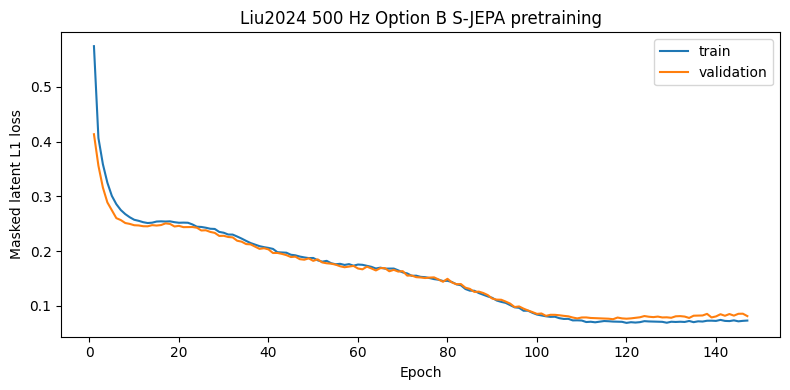

In [11]:
metrics_df = pd.DataFrame(metrics)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metrics_df["epoch"], metrics_df["train_loss"], label="train")
ax.plot(metrics_df["epoch"], metrics_df["val_loss"], label="validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("Masked latent L1 loss")
ax.set_title("Liu2024 500 Hz Option B S-JEPA pretraining")
ax.legend()
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "pretraining_loss_curve.png", dpi=160)
plt.show()

## 12. Notes, config guidance, and 128 Hz vs 500 Hz

**What changed (concrete fixes).**
1. Removed the braindecode `SignalJEPA` dependency; implemented a self-contained, faithful S-JEPA
   (per-channel conv feature encoder, finite spatial+temporal positional encoder, context encoder,
   EMA target encoder, spatial-block masking, smooth-L1 latent prediction).
2. **Fixed the spatial-positional NaN at its root**: channel coordinates are centered and scaled
   to the unit ball with an epsilon; the spatial embedding is an MLP on those normalized
   coordinates (no internal division-by-zero possible).
3. Robust `build_channel_coordinates`: `standard_1020` + old-name aliases, finite/degenerate/
   duplicate checks, a printed coordinate audit, and clear errors.
4. Kept and extended finite checks (input, local, **spatial PE**, **temporal PE**, combined PE,
   context, predictor, loss) and a probe that isolates spatial vs temporal so any future NaN is
   localized immediately rather than hidden.
5. Lowered `learning_rate` to 1e-4 and added gradient clipping + pre-LN transformers for stable
   SSL training; SSL is subject-clean (train 1–30, val 31–40, 41–50 untouched, no labels in loss).

**Config guidance.** Defaults follow your recommended config. If training is unstable, lower
`learning_rate` further or reduce `context_n_layers`; if it underfits, raise `n_epochs`. The
per-sample loss loop (needed because the mask differs per sample) is the throughput bottleneck —
fine for this dataset size.

**Is 500 Hz worth it vs 128 Hz?** Honestly, probably not much for this task. The MI information is
oscillatory in 8–30 Hz, which 128 Hz already resolves (Nyquist 64 Hz); 500 Hz mostly adds ~4×
samples/tokens and compute without new band-limited information, and your covariance/Riemannian
analyses decoded fine at both rates. The defensible reasons to keep 500 Hz here are (a) avoiding
the resample-window-shrink artifact from the earlier audit and (b) matching the native pipeline
the classical baseline used — not an expectation of better representations. If pretraining is slow
or unstable, 128 Hz Option-A with the same architecture is a reasonable, cheaper comparison.